In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,
                    columns=housing.feature_names)
data["Price"]=housing.target

In [4]:
x=data[['AveRooms']].values
y=data['Price'].values

In [5]:
data.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [6]:
data.shape


(20640, 9)

In [7]:
x_train, x_test, y_train, y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler=StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
w=0
b=0
learning_rate=0.01
epochs=1000
cost_history=[]
n=len(x_train_scaled)
for i in range(epochs):
    y_pred=w*x_train_scaled.flatten()+b
    dw=(1/n)*np.sum((y_pred - y_train)*x_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred - y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    if i% 100==0:
        cost=(1/(2*n)) * np.sum((y_pred - y_train) ** 2)
        cost_history.append(cost)
        print(f"Epoch {i}, Cost={cost:.4f}")
        
y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, Cost=2.8149
Epoch 100, Cost=0.9414
Epoch 200, Cost=0.6904
Epoch 300, Cost=0.6568
Epoch 400, Cost=0.6523
Epoch 500, Cost=0.6517
Epoch 600, Cost=0.6516
Epoch 700, Cost=0.6516
Epoch 800, Cost=0.6516
Epoch 900, Cost=0.6516


In [10]:
print("Gradient Descent")
print("----------------")
print("Weight: ",w)
print("Bias: ",b)
print("MSE: ",mean_squared_error(y_test,y_pred_gd))
print("R2 Score:", r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight:  0.18323090648660517
Bias:  2.0718574888450205
MSE:  1.292327655590046
R2 Score: 0.013798228607320828


In [11]:
#Normal equation
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne= np.c_[np.ones((len(x_test),1)),x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta
                           

In [12]:
print("\nNormal Equation")
print("-----------------")
print("Intercept: ",theta[0])
print("Slope:",theta[1])
print("MSE:" , mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))
      


Normal Equation
-----------------
Intercept:  1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


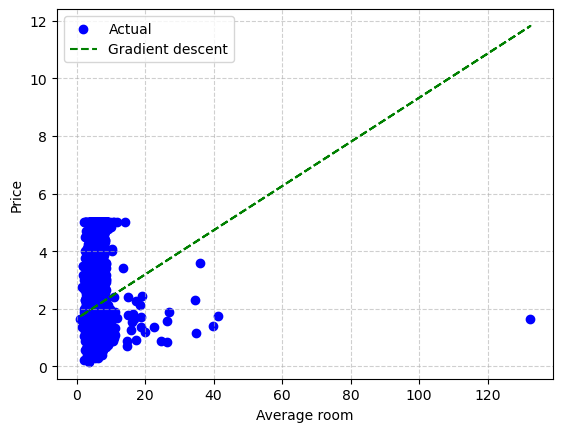

In [19]:
plt.scatter(x_test,y_test,color="blue",label="Actual")
plt.plot(x_test,y_pred_gd,color="greenplt.grid(True,linestyle='--',alpha=0.6)",linestyle="--",label="Gradient descent")
plt.grid(True,linestyle='--',alpha=0.6)
plt.xlabel("Average room")
plt.ylabel("Price")
plt.legend()
plt.show()

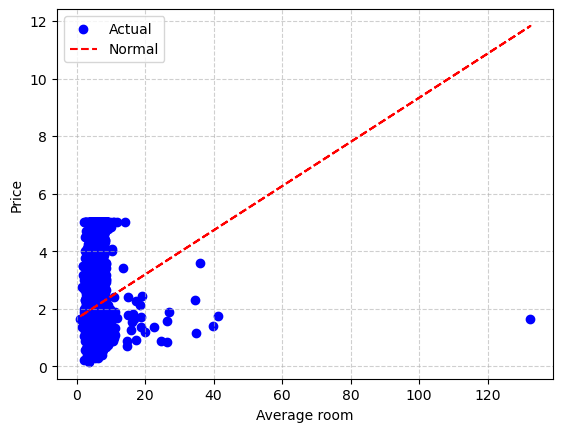

In [20]:
plt.scatter(x_test,y_test,color="blue",label="Actual")
plt.plot(x_test,y_pred_ne,color="red",linestyle="--",label="Normal")
plt.grid(True,linestyle='--',alpha=0.6)
plt.xlabel("Average room")
plt.ylabel("Price")
plt.legend()
plt.show()

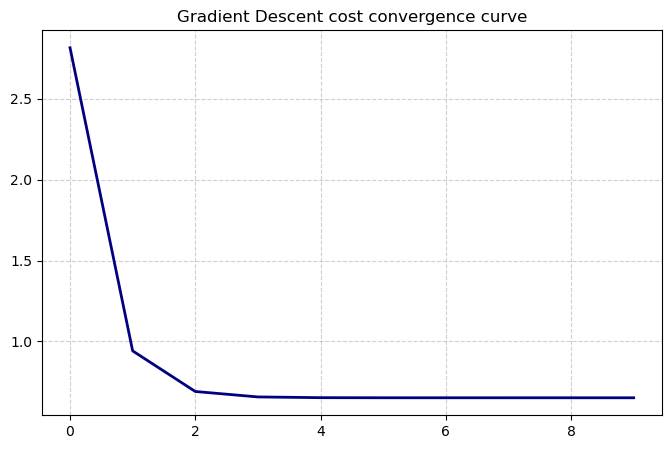

In [22]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title("Gradient Descent cost convergence curve")
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

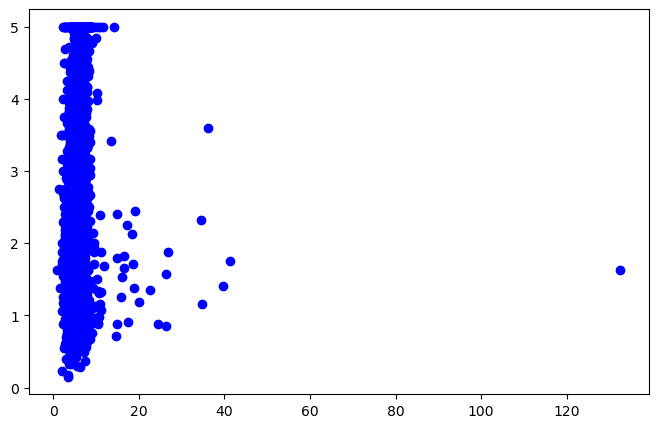

In [24]:
index=np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x_test,y_test,color='blue',label='Actual Data')

<function matplotlib.pyplot.show(close=None, block=None)>

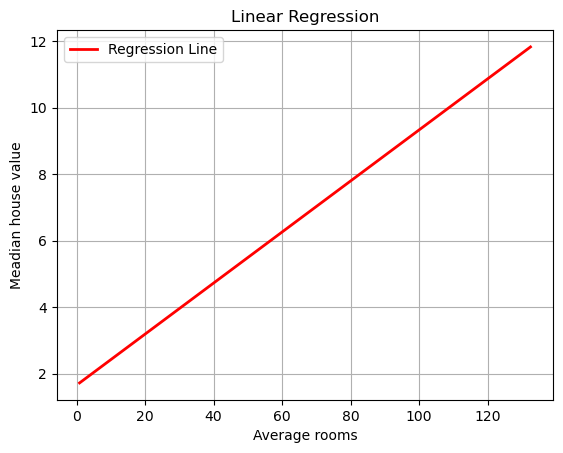

In [30]:
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label="Regression Line")
plt.title("Linear Regression")
plt.xlabel("Average rooms")
plt.ylabel("Meadian house value")
plt.legend()
plt.grid(True)
plt.show
